<a href="https://colab.research.google.com/github/DanisStepanov/image_processing/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D0%BD%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_OpenCV_%D0%A7%D0%B0%D1%81%D1%82%D1%8C_%E2%84%961_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №1. Основные методы OpenCV. Часть №1**

---

# **Тема №1. Чтение, запись и отображение**



## **Задание 1:**  
Напишите процедуру, которая:

- Считывает цветное изображение в режиме `cv2.IMREAD_COLOR`.
- Преобразует его в оттенки серого с использованием `cv2.cvtColor()`.
- Сохраняет полученное черно-белое изображение на диск.
- Отображает оба изображения (оригинальное цветное и преобразованное черно-белое).




In [1]:
import cv2 as cv
import cv2 as cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
# Ссылка на файл для скачивания
url = r'https://2spalnika.ru/wp-content/uploads/2022/12/zhivotniy-mir-hibin-800x600.jpg'

# Скачиваем файл с помощью wget
!wget -O arctic_fox.jpg '{url}'

--2026-09-12 11:38:33--  https://2spalnika.ru/wp-content/uploads/2022/12/zhivotniy-mir-hibin-800x600.jpg
Resolving 2spalnika.ru (2spalnika.ru)... 87.236.16.233
Connecting to 2spalnika.ru (2spalnika.ru)|87.236.16.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105772 (103K) [image/jpeg]
Saving to: ‘arctic_fox.jpg’

arctic_fox.jpg      100%[===================>] 103.29K   239KB/s    in 0.4s    

2026-09-12 11:38:35 (239 KB/s) - ‘arctic_fox.jpg’ saved [105772/105772]



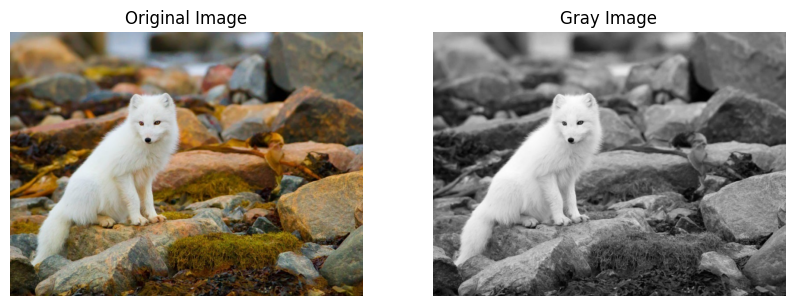

In [2]:
# Путь к изображению
image_path = 'arctic_fox.jpg'
img_color = cv.imread(image_path, cv2.IMREAD_COLOR)
gray_img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
cv2.imwrite('gray_image.jpg', gray_img)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.axis('off')

plt.show()

## **Задание 2:**  
Используя режим `cv2.IMREAD_UNCHANGED`, загрузите изображение с альфа-каналом (например, PNG с прозрачностью). Затем:

- Разделите изображение на каналы (B, G, R, A).
- Создайте новое изображение, где прозрачность (альфа-канал) инвертирована (т.е. прозрачные области становятся непрозрачными и наоборот).
- Сохраните и отобразите полученное изображение.

In [66]:
!wget -O test.png 'https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original'

--2026-09-12 14:02:49--  https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.240, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 224566 (219K) [image/png]
Saving to: ‘test.png’

test.png            100%[===================>] 219.30K  --.-KB/s    in 0.07s   

2026-09-12 14:02:49 (3.20 MB/s) - ‘test.png’ saved [224566/224566]



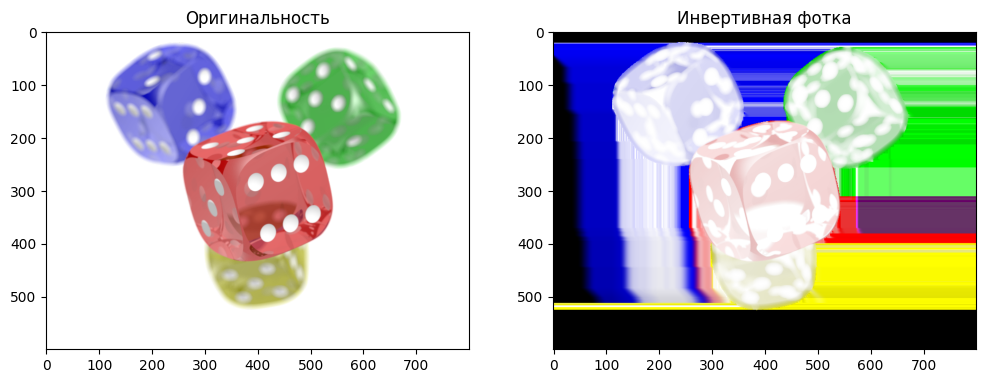

In [69]:
bgra = cv.imread("test.png", cv.IMREAD_UNCHANGED)
b, g, r, a = cv.split(bgra)
a_inv = 255 - a
bgra_inv = cv.merge([b, g, r, a_inv])
cv.imwrite("inverter.png", bgra_inv)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv.cvtColor(bgra, cv.COLOR_BGRA2RGBA))
ax[0].set_title("Оригинальность")
ax[1].imshow(cv.cvtColor(bgra_inv, cv.COLOR_BGRA2RGBA))
ax[1].set_title("Инвертивная фотка")
plt.show()

---

# **Тема №2. Работа с цветовыми палитрами**



## **Задание 3:**  
Напишите процедуру, которая:

- Считывает цветное изображение.
- Преобразует его из цветового пространства BGR в HSV с помощью `cv2.cvtColor()`.
- Увеличивает насыщенность (канал S) в 1.5 раза, не превышая максимального значения.
- Преобразует изображение обратно в цветовое пространство BGR.
- Отображает оригинальное и полученное изображения рядом для сравнения.

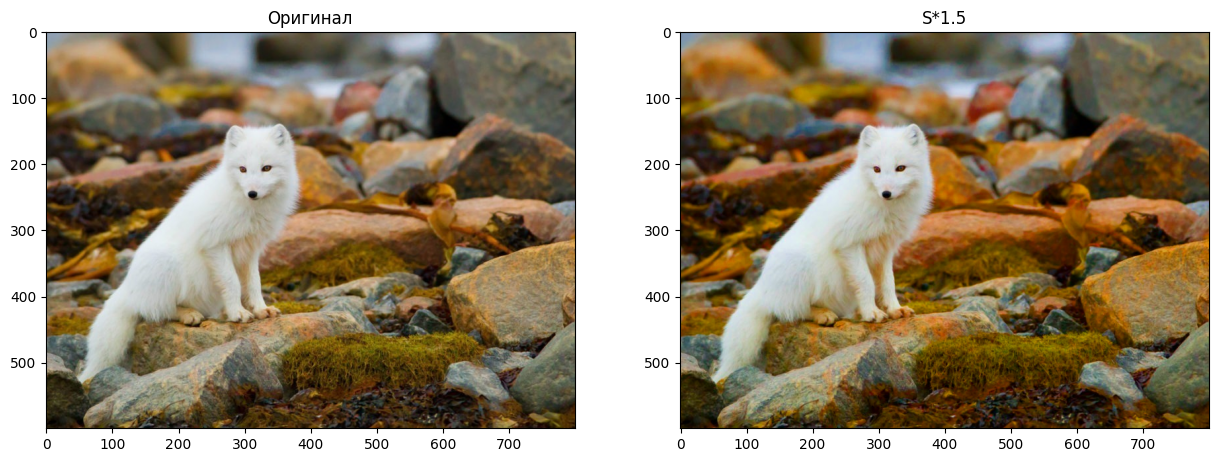

In [25]:
hsv_img = cv2.cvtColor(img_color, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv_img)
S_up = cv.multiply(S, 1.5)
hsv_up = cv.merge([H, S_up, V])
img_rezult = cv.cvtColor(hsv_up, cv.COLOR_HSV2BGR)
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
ax[0].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
ax[0].set_title("Оригинал")
ax[1].imshow(cv.cvtColor(img_rezult, cv.COLOR_BGR2RGB))
ax[1].set_title("S*1.5")
plt.show()

## **Задание 4:**  
Напишите процедуру, которая:

- Считывает изображение и Преобразует его в цветовое пространство YCrCb.
- Применяет размытие к компоненте яркости Y (при помощи фильтра, см. материал предыдущих занятий).
- Снова Преобразует изображение в цветовое пространство BGR.
- Отображает исходное и размытое изображения.

In [11]:
url = r'https://images.steamusercontent.com/ugc/1833551576420464068/6D5FF0CF2C48F8351C9AAC98363DEC31386678AB/?imw=5000&amp;imh=5000&amp;ima=fit&amp;impolicy=Letterbox&amp;imcolor=%23000000&amp;letterbox=false'
!wget -O invoker.jpg '{url}'

img = cv.imread('invoker.jpg', cv.IMREAD_COLOR)


--2026-09-12 12:08:53--  https://images.steamusercontent.com/ugc/1833551576420464068/6D5FF0CF2C48F8351C9AAC98363DEC31386678AB/?imw=5000&amp;imh=5000&amp;ima=fit&amp;impolicy=Letterbox&amp;imcolor=%23000000&amp;letterbox=false
Resolving images.steamusercontent.com (images.steamusercontent.com)... 23.1.255.197, 23.1.255.201, 2600:1409:3c00:b::172c:af07, ...
Connecting to images.steamusercontent.com (images.steamusercontent.com)|23.1.255.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54766 (53K) [image/jpeg]
Saving to: ‘invoker.jpg’

invoker.jpg         100%[===================>]  53.48K  --.-KB/s    in 0.002s  

2026-09-12 12:08:54 (24.4 MB/s) - ‘invoker.jpg’ saved [54766/54766]



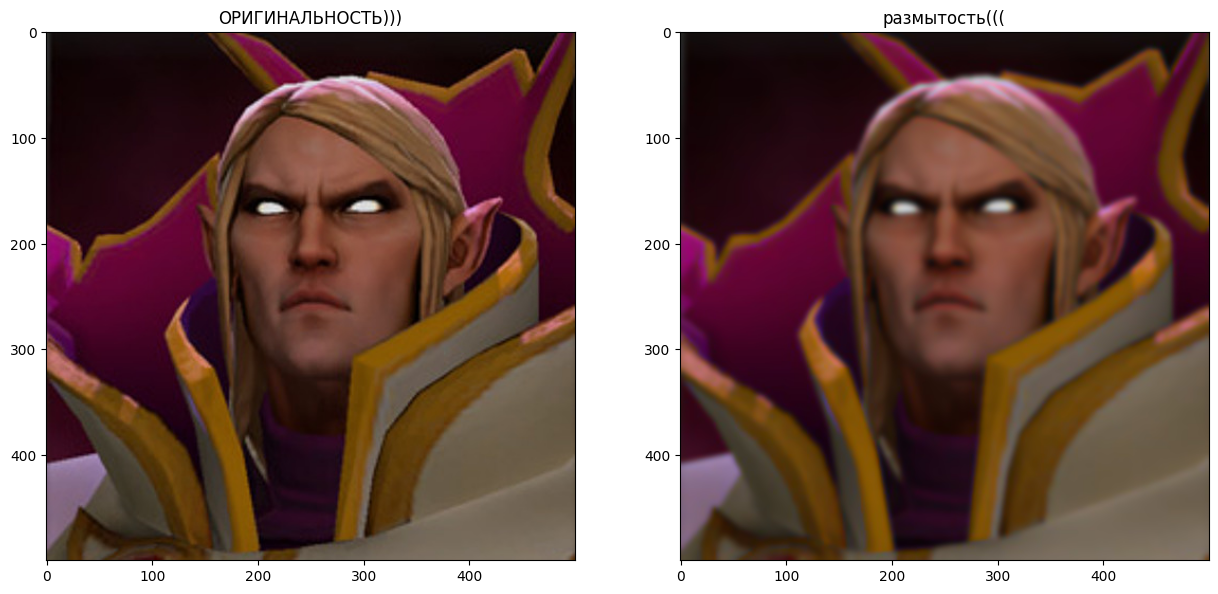

In [24]:
YCrCb_image = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)

Y  = YCrCb_image[:, :, 0]
Cr = YCrCb_image[:, :, 1]
Cb = YCrCb_image[:, :, 2]

Y_razmt = cv.GaussianBlur(Y, (15, 15), 0)
YCrCb_razmt = cv.merge([Y_razmt, Cr, Cb])
img_rezult2 = cv.cvtColor(YCrCb_razmt, cv.COLOR_YCrCb2BGR)

fig, ax = plt.subplots(1, 2, figsize=(15, 10))
ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0].set_title("ОРИГИНАЛЬНОСТЬ)))")
ax[1].imshow(cv.cvtColor(img_rezult2, cv.COLOR_BGR2RGB))
ax[1].set_title("размытость(((")
plt.show()

---

# **Тема №3. Слияние и усиление**

## **Задание 5:**  
Создайте процедуру, которая:

- Считывает два изображения одинакового размера (можно подкорректировать с помощью метода `.resize()`).
- Выполняет побитовое ИЛИ (OR) над соответствующими пикселями двух изображений.
- Сохраняет и отображает результат операции.

In [19]:
url = r'https://storage.vscl.ru/avatars/b1/5d/6a/b15d6ac920261fff4056226cebde9e45fa3c798d.png?s=400'
!wget -O pudge.jpg '{url}'

img_pudge = cv.imread('pudge.jpg', cv.IMREAD_COLOR)

--2026-09-12 12:23:10--  https://storage.vscl.ru/avatars/b1/5d/6a/b15d6ac920261fff4056226cebde9e45fa3c798d.png?s=400
Resolving storage.vscl.ru (storage.vscl.ru)... 164.215.71.31
Connecting to storage.vscl.ru (storage.vscl.ru)|164.215.71.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 253134 (247K) [image/png]
Saving to: ‘pudge.jpg’

pudge.jpg           100%[===================>] 247.20K   349KB/s    in 0.7s    

2026-09-12 12:23:12 (349 KB/s) - ‘pudge.jpg’ saved [253134/253134]



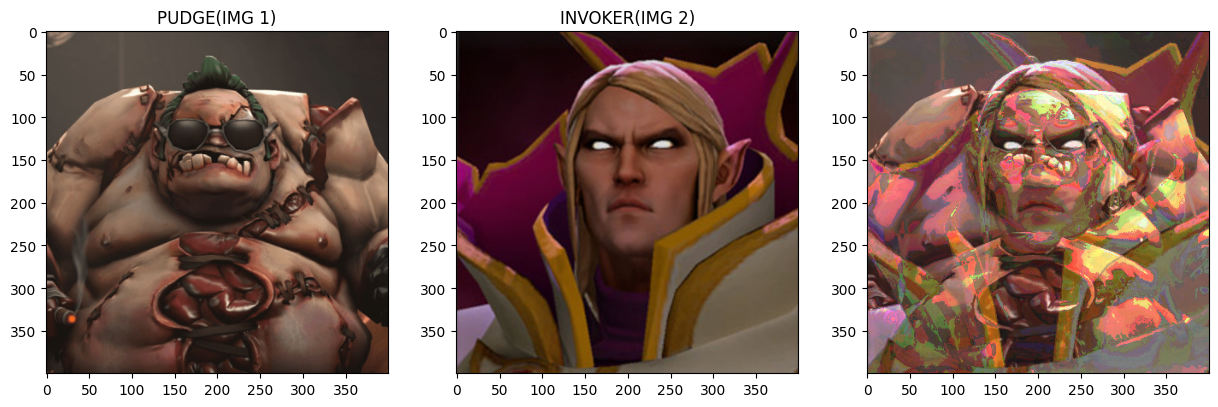

In [23]:
img1 = cv.imread('pudge.jpg', cv.IMREAD_COLOR)
img2 = cv.imread('invoker.jpg', cv.IMREAD_COLOR)
h, w = img1.shape[:2]
img2_rezult3 = cv.resize(img2, (w, h))
img_or = cv.bitwise_or(img1, img2_rezult3)
cv.imwrite('bit.jpg', img_or)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB));
ax[0].set_title("PUDGE(IMG 1)");
ax[1].imshow(cv.cvtColor(img2_rezult3, cv.COLOR_BGR2RGB));
ax[1].set_title("INVOKER(IMG 2)");
ax[2].imshow(cv.cvtColor(img_or, cv.COLOR_BGR2RGB));
plt.show()

## **Задание 6:**  
Реализуйте следующий алгоритм:

- Считайте цветное изображение и разделите его на три канала с использованием `.split()`.
- Примените к каждому каналу разный коэффициент гамма-коррекции (например, для R – 0.5, G – 1.0, B – 1.5).
- Объедините каналы обратно с помощью `.merge()`.
- Отобразите исходное и обработанное изображения.


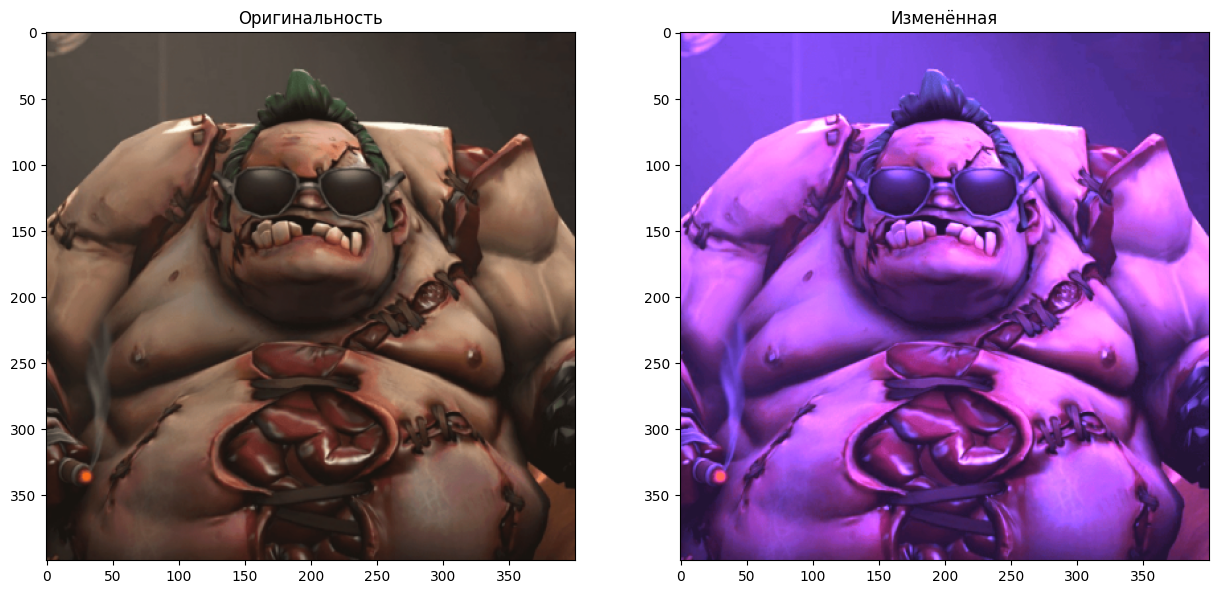

In [34]:
b, g, r = cv.split(img_pudge)
r_nov = cv.multiply(r, 1.5)
g_nov = cv.multiply(g, 1.0)
b_nov = cv.multiply(b, 3.5)
img_rezult4 = cv.merge([b_nov, g_nov, r_nov])
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
ax[0].imshow(cv.cvtColor(img_pudge, cv.COLOR_BGR2RGB))
ax[0].set_title("Оригинальность")
ax[1].imshow(cv.cvtColor(img_rezult4, cv.COLOR_BGR2RGB))
ax[1].set_title("Изменённая")
plt.show()

# **Тема №4. Работа с гистограммами в OpenCV**

## **Задание 7:**  
Напишите процедуру для улучшения контрастности изображения:

- Считывает изображение в оттенках серого.
- Строит его гистограмму с использованием `cv.calcHist()`.
- Применяет эквализацию гистограммы методом `cv2.equalizeHist()`.
- Отображает на одном графике исходное и эквализованное изображения вместе с их гистограммами.

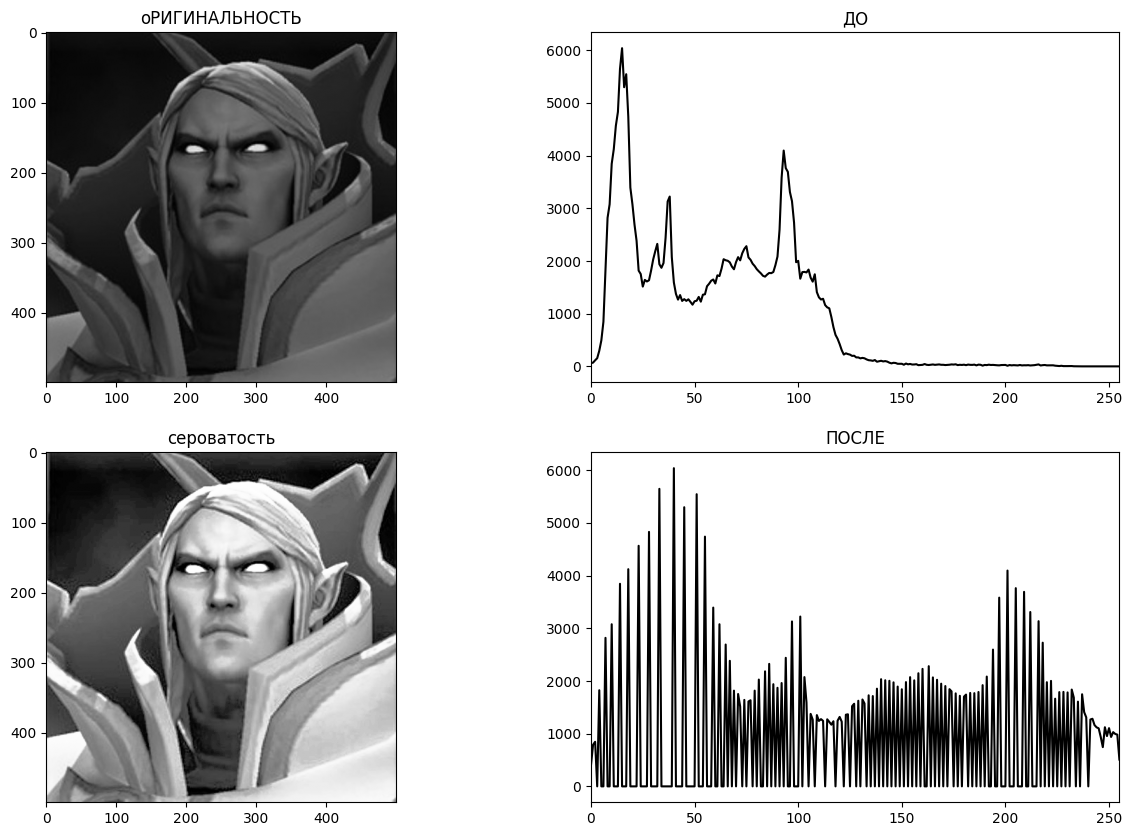

In [41]:
gray = cv.imread('arctic_fox.jpg', cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([gray], [0], None, [256], [0, 256])
equalized = cv.equalizeHist(gray)
hist_eq = cv.calcHist([equalized], [0], None, [256], [0, 256])

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].imshow(gray, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title("оРИГИНАЛЬНОСТЬ")

ax[0, 1].plot(hist, color='black')
ax[0, 1].set_title("ДО")
ax[0, 1].set_xlim([0, 255])

ax[1, 0].imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax[1, 1].plot(hist_eq, color='black')
ax[1, 0].set_title("сероватость")
ax[1, 1].set_title("ПОСЛЕ")
ax[1, 1].set_xlim([0, 255])
plt.show()

## **Задание 8:**  
Используйте метод CLAHE для улучшения деталей в затемненных областях цветного изображения:

- Преобразуйте изображение из BGR в LAB цветовое пространство.
- Разделите изображение на каналы и примените `cv2.createCLAHE()` к каналу яркости L.
- Объедините обработанный канал L с исходными каналами A и B.
- Преобразуйте изображение обратно в BGR.
- Отобразите исходное и обработанное изображения для сравнения вместе с их гистограммами.

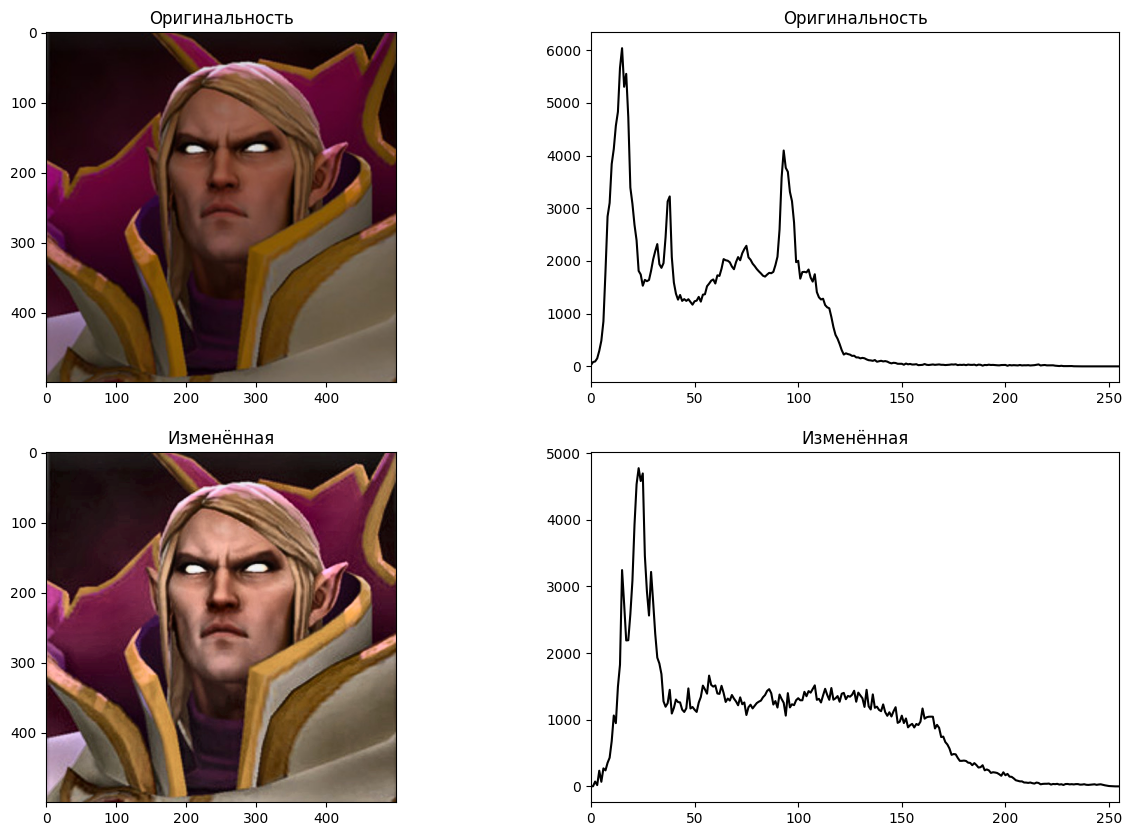

In [74]:
lab_image = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, A, B = lab_image[:, :, 0], lab_image[:, :, 1], lab_image[:, :, 2]

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_clahe = clahe.apply(L)

lab_clahe = cv.merge([L_clahe, A, B])
clahe_eq_img = cv.cvtColor(lab_clahe, cv.COLOR_LAB2BGR)

y_src = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)[:, :, 0]
y_dst = cv.cvtColor(clahe_eq_img, cv.COLOR_BGR2YCrCb)[:, :, 0]
hist_src = cv.calcHist([y_src], [0], None, [256], [0, 256])
hist_clahe = cv.calcHist([y_dst], [0], None, [256], [0, 256])

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0, 0].set_title("Оригинальность")

ax[1, 0].imshow(cv.cvtColor(clahe_eq_img, cv.COLOR_BGR2RGB))
ax[1, 0].set_title("Изменённая")

ax[0, 1].plot(hist_src, color='black')
ax[0, 1].set_title("Оригинальность")
ax[0, 1].set_xlim([0, 255])

ax[1, 1].plot(hist_clahe, color='black')
ax[1, 1].set_title("Изменённая")
ax[1, 1].set_xlim([0, 255])
plt.show()

## **Затем:**  
Исследуйте влияние размера окна (tileGridSize) и порога по сравнению с гистограммой (clipLimit) в методе CLAHE на конечный результат. Попробуйте несколько различных значений и визуализируйте результаты.


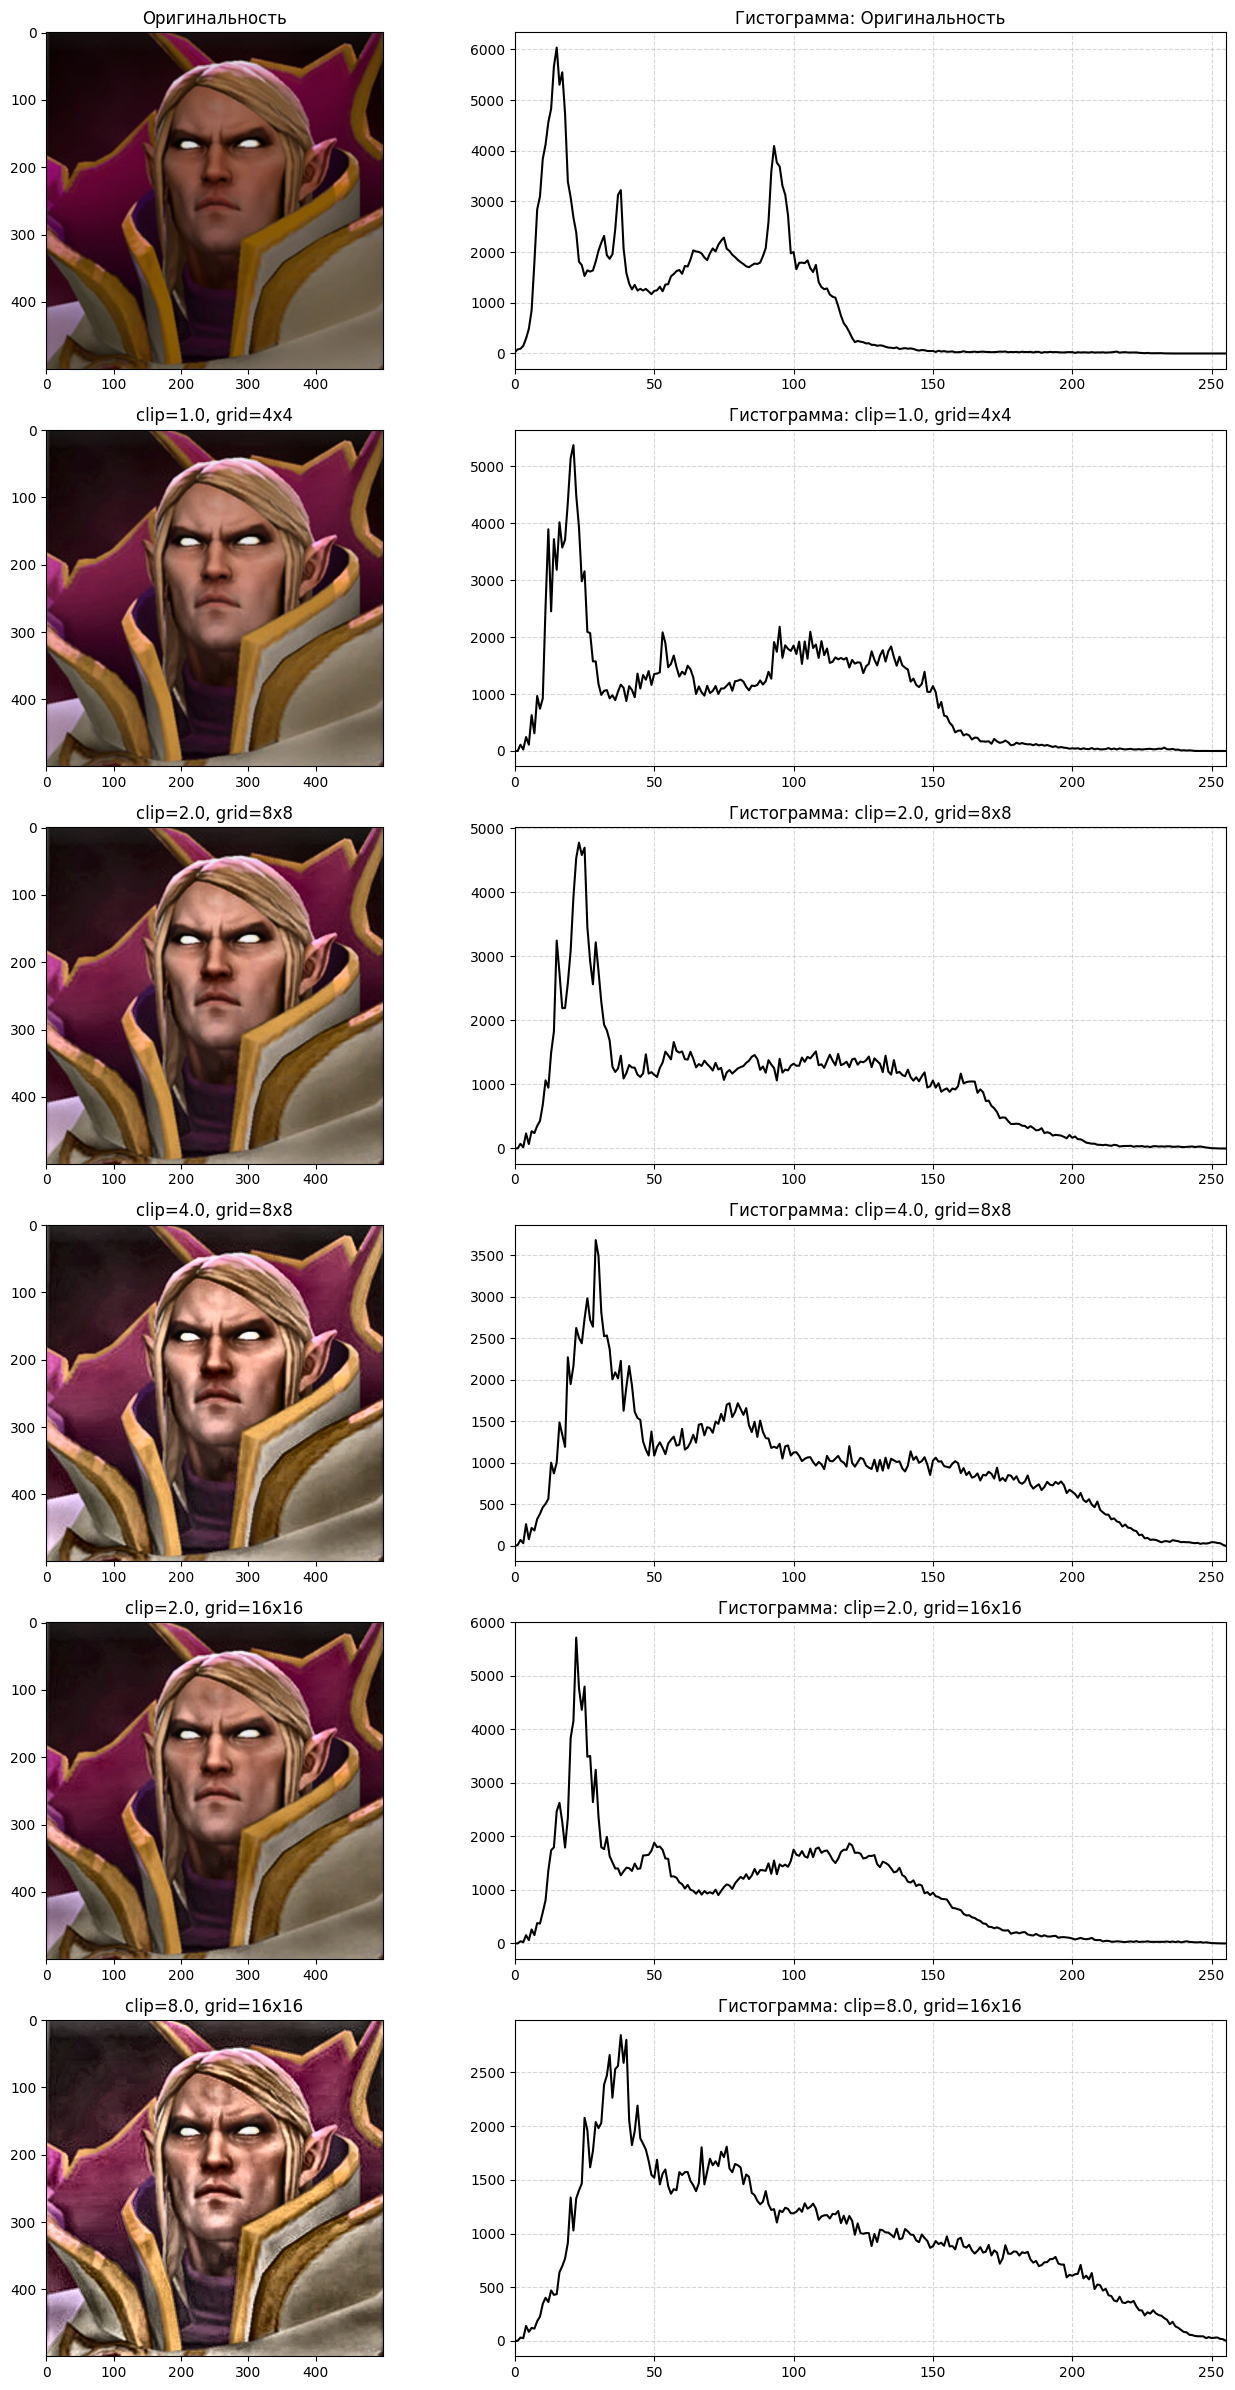

In [86]:
def func1(src_img, clip_limit, tile_grid_size):
    lab = cv.cvtColor(src_img, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    clahe_local = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab_eq = cv.merge([clahe_local.apply(l), a, b])
    return cv.cvtColor(lab_eq, cv.COLOR_LAB2BGR)
variants = [
    (1.0, (4, 4),   "clip=1.0, grid=4x4"),
    (2.0, (8, 8),   "clip=2.0, grid=8x8"),
    (4.0, (8, 8),   "clip=4.0, grid=8x8"),
    (2.0, (16, 16), "clip=2.0, grid=16x16"),
    (8.0, (16, 16), "clip=8.0, grid=16x16"),
]

results = [func1(img, clip, grid) for clip, grid, _ in variants]

#КАЮСЬ использовал ИИ, для того чтобы вывести результат красивым

all_images = [img] + results
all_titles = ["Оригинальность"] + [v[2] for v in variants]
num_rows = len(all_images)
fig, ax = plt.subplots(num_rows, 2, figsize=(14, 4 * num_rows))

for i in range(num_rows):
    current_img = all_images[i]
    current_title = all_titles[i]

    ax[i, 0].imshow(cv.cvtColor(current_img, cv.COLOR_BGR2RGB))
    ax[i, 0].set_title(current_title)

    y_channel = cv.cvtColor(current_img, cv.COLOR_BGR2YCrCb)[:, :, 0]
    hist = cv.calcHist([y_channel], [0], None, [256], [0, 256])

    ax[i, 1].plot(hist, color="black")
    ax[i, 1].set_title(f"Гистограмма: {current_title}")
    ax[i, 1].set_xlim([0, 255])
    ax[i, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---

# **Комплексное задание №1. Улучшение качества отсканированного документа с использованием OpenCV**



## **Краткое описание задания:**

- Необходимо написать функцию для улучшения качества отсканированного документа с использованием методов обработки изображений, изученных ранее. Функция должна принимать на вход изображение отсканированного документа и возвращать его улучшенную версию, готовую для дальнейшего использования, например, для распознавания текста.

Датасет с отсканированными изображениями можно найти в сети Интернет.

---



## **Алгоритм действий:**

#### **Реализуйте функцию на языке Python с использованием библиотеки OpenCV, которая выполняет следующие этапы обработки:**

### **1. Чтение, запись и отображение изображений:**

- Функция должна принимать на вход изображение отсканированного документа (например, в формате JPEG или PNG)
- Проверьте наличие альфа-канала в изображении и, если он присутствует, загрузите изображение в режиме `cv2.IMREAD_UNCHANGED`, иначе используйте `cv2.IMREAD_COLOR`
- Отобразите исходное изображение для визуальной проверки

### **2. Работа с цветовыми палитрами:**

- Преобразуйте изображение в оттенки серого, используя `cv2.cvtColor()` с параметром `cv2.COLOR_BGR2GRAY`.
- Отобразите полученное изображение в оттенках серого.

### **3. Слияние и усиление:**

- Примените медианный фильтр (`cv2.medianBlur()`) для удаления шумов с изображения. Выберите подходящий размер ядра (например, 3 или 5). Отобразите результат.
- Используйте фильтр сглаживания с применением прямой свертки (`cv2.filter2D()`) с заданным ядром для повышения четкости. Например, можно использовать фильтр "Unsharp Masking":
  - Создайте ядро для повышения резкости. Пример ядра:
    ```python
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    ```
  - Примените фильтр к изображению и отобразите результат.

### **4. Работа с гистограммами:**

- Примените метод CLAHE (Contrast Limited Adaptive Histogram Equalization) для улучшения контрастности изображения:
  - Создайте объект CLAHE с параметрами `clipLimit=2.0` и `tileGridSize=(8,8)`.
  - Примените CLAHE к изображению.
  - отобразите результат.
- Постройте гистограммы яркости исходного и обработанного изображений для сравнения.

---

### **Требования к функции:**

- Функция должна называться: `improve_scan(image)`, где `image` — входное изображение в виде массива NumPy.
- Функция должна возвращать улучшенное изображение в виде массива NumPy.
- В ходе работы функция должна **опционально** отображать промежуточные результаты для наглядности (в условиях Colab использовать соответствующие методы вывода изображений). Для этого следует ввести отдельный параметр (например: `visible=True`) и реализовать с ним соответствующую логику.

---

### **Дополнительные требования:**

- **Обработка ошибок:**
  - Убедитесь, что функция корректно обрабатывает ситуации, когда на вход подается некорректное изображение.
  - Добавьте проверки на тип входных данных.

- **Документация и комментарии:**
  - Функция должна быть снабжена понятной документацией: опишите, какие преобраования выполняются и для чего.
  - Добавьте комментарии к основным участкам кода для пояснения выполняемых действий.



---

### **Подсказки и рекомендации:**


- **Медианный фильтр:**
  Функция `cv2.medianBlur(src, ksize)` принимает на вход изображение и размер ядра (должен быть нечетным числом).

- **CLAHE:**
  - Создайте объект CLAHE с помощью `cv2.createCLAHE(clipLimit, tileGridSize)`.
  - Примените метод `apply()` к изображению в оттенках серого.

- **Отображение изображений в Google Colab:**
  - Используйте `matplotlib.pyplot` для отображения изображений.
  - Помните, что `cv2.imread()` загружает изображения в формате BGR, поэтому для корректного отображения в Matplotlib Преобразуйте изображение в RGB с помощью `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.

---

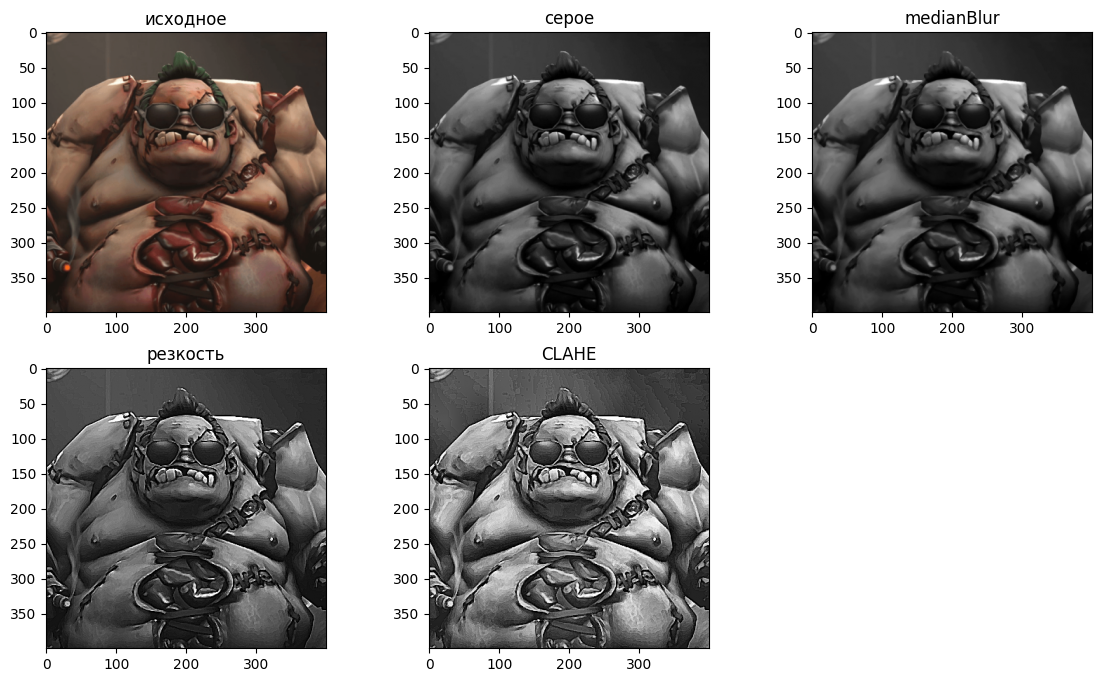

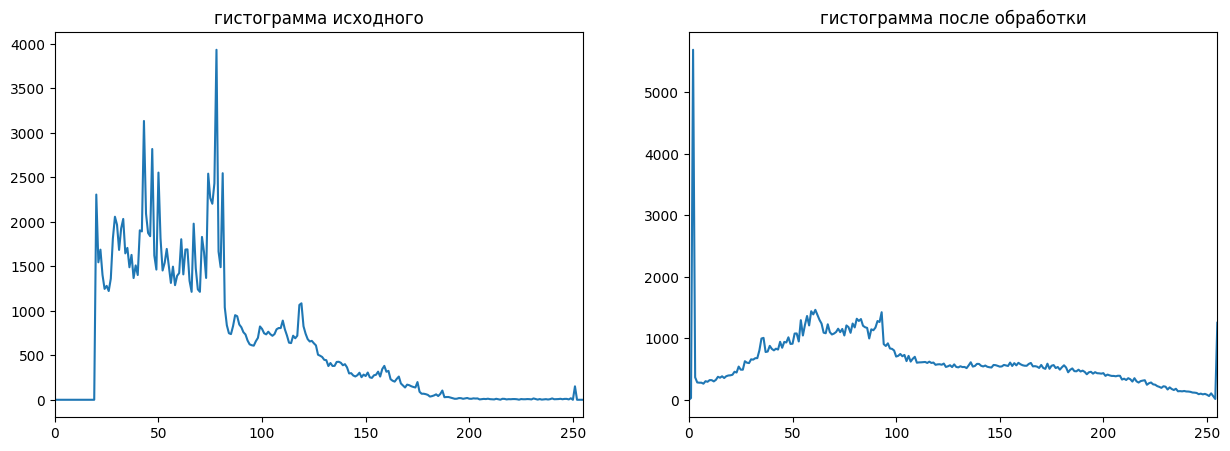

In [95]:
def improve_scan(image, visible=True):
    # Тут выполняются проверки пустой ли массив, пустая ли картинка и количество каналов
    if image is None or not isinstance(image, np.ndarray):
        print("Массив пустой")
    if image.size == 0 or image.ndim not in (2, 3):
        print("Пустая картинка")
    if image.ndim == 3 and image.shape[2] not in (3, 4):
        print("должно быть 1, 3 или 4 канала")

    # Если картинка пришла с каналом альфой, она конвертиурет его в BGRA, так же с чёрно-белым, оно так же конвертируется в BGR.
    # Ну и если картинка итак BGR то всё кайф
    if image.ndim == 3 and image.shape[2] == 4:
        bgr = cv.cvtColor(image, cv.COLOR_BGRA2BGR)
    elif image.ndim == 2:
        bgr = cv.cvtColor(image, cv.COLOR_GRAY2BGR)
    else:
        bgr = image.copy()

    # в серый
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

    #Чуть убираем шим с картинки, но при этом не сильно размываем границы
    blur = cv.medianBlur(gray, 3)

    # Здали матрицу для повышения резкости на фотке
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    #Пропускаем нашу фотку через нашу матрицу фильтров
    sharp = cv.filter2D(blur, -1, kernel)

    #Создаём выравниватель констраста, разбивает картинку 8 на 8 пикс. и выравнивает яркость в каждом пикс.
    #с ограничителем 2
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    out = clahe.apply(sharp)
    #Тут начинается визуализация
    if visible:
        steps = [
            (cv.cvtColor(bgr, cv.COLOR_BGR2RGB), "исходное", None),
            (gray, "серое", "gray"),
            (blur, "medianBlur", "gray"),
            (sharp, "резкость", "gray"),
            (out, "CLAHE", "gray"),
        ]#создали массив куда поместили все варианты фотки после всех обработок и подписали их
        #картинки
        plt.figure(figsize=(14, 8))
        for i, (im, title, cmap) in enumerate(steps, start=1):
            plt.subplot(2, 3, i)
            if cmap:
                plt.imshow(im, cmap="gray")
            else:
                plt.imshow(im)
            plt.title(title)
        plt.show()

        # гистограммы до/после
        h1 = cv.calcHist([gray], [0], None, [256], [0, 256])
        h2 = cv.calcHist([out], [0], None, [256], [0, 256])

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(h1)
        plt.title("гистограмма исходного")
        plt.xlim([0, 255])

        plt.subplot(1, 2, 2)
        plt.plot(h2)
        plt.title("гистограмма после обработки")
        plt.xlim([0, 255])
        plt.show()

#Тут запускается всё
path = "pudge.jpg"
scan = cv.imread(path, cv.IMREAD_UNCHANGED)
result = improve_scan(scan, visible=True)

## **Дополнительное задание:**

- Поэкспериментируйте с параметрами медианного фильтра, ядром для фильтра повышения резкости и параметрами CLAHE для достижения наилучшего результата.
- Добавьте возможность передачи этих параметров в функцию `improve_scan` для более гибкой настройки обработки. **В качестве параметров по умолчанию установите те, которые показали себя лучше всего по результатам экспериментов**

**Пример с параметрами:**

```python
def improve_scan(image,
                 median_kernel_size=3,
                 sharp_kernel= np.array([[-1, -1, -1],
                                         [-1,  9, -1],
                                         [-1, -1, -1]]),
                 clahe_clip=2.0,
                 clahe_grid=(8,8),
                 visible=True):
    # Реализация с учетом переданных параметров
    ...
```


In [ ]:
# Ваш код